In [1]:
import pandas as pd

In [2]:
NE2 = pd.read_csv('../data_estaciones/BD_NE2_limpia.csv')
NE3 = pd.read_csv('../data_estaciones/BD_NE3_limpia.csv')

ndvi_mensual = pd.read_csv('../data_estaciones/ndvi_mensual_estaciones_2020_2025.csv')

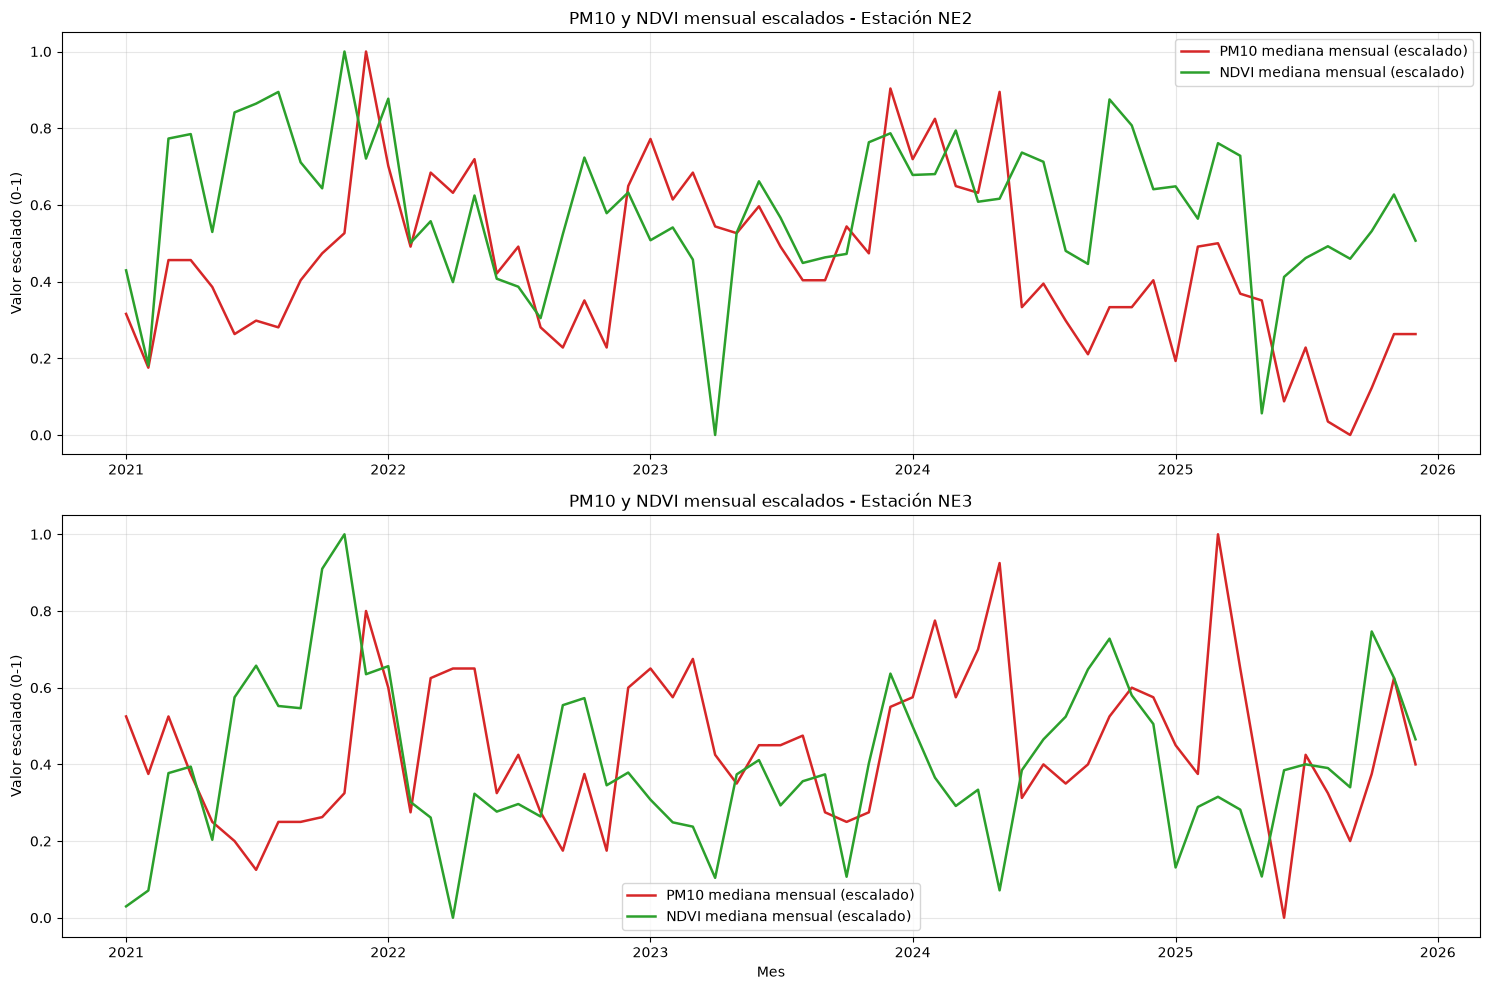

(         mes  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2021-01-01          52.0      0.035765       0.315789       0.429339
 1 2021-02-01          44.0      0.016555       0.175439       0.181351
 2 2021-03-01          60.0      0.062388       0.456140       0.773041
 3 2021-04-01          60.0      0.063291       0.456140       0.784696
 4 2021-05-01          56.0      0.043520       0.385965       0.529460,
          mes  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2021-01-01          36.0      0.024677          0.525       0.029719
 1 2021-02-01          30.0      0.044841          0.375       0.071137
 2 2021-03-01          36.0      0.193872          0.525       0.377256
 3 2021-04-01          30.0      0.202109          0.375       0.394176
 4 2021-05-01          25.0      0.109191          0.250       0.203317)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def escalar_min_max(serie):
    """Escala una serie al intervalo [0, 1], ignorando valores faltantes."""
    minimo = serie.min()
    maximo = serie.max()
    if pd.isna(minimo) or minimo == maximo:
        return serie * 0
    return (serie - minimo) / (maximo - minimo)


def preparar_datos_estacion(datos_horarios, nombre_estacion):
    """Calcula medianas mensuales horarias y las combina con el NDVI mensual."""
    columnas_valores = datos_horarios.columns.difference(["anio", "date"])
    datos_numericos = datos_horarios.copy()
    datos_numericos[columnas_valores] = datos_numericos[columnas_valores].apply(
        pd.to_numeric, errors="coerce"
    )

    datos_mensuales = (
        datos_numericos.assign(
            mes=datos_numericos["date"].dt.to_period("M").dt.to_timestamp()
        )
        .groupby("mes", as_index=False)[list(columnas_valores)]
        .median()
        .rename(
            columns={
                columna: f"{columna}_mediana"
                for columna in columnas_valores
            }
        )
    )

    ndvi_estacion = ndvi_mensual.loc[
        ndvi_mensual["estacion"] == nombre_estacion,
        ["mes", "ndvi_mediana"],
    ]
    datos_mensuales = datos_mensuales.merge(
        ndvi_estacion, on="mes", how="left"
    ).sort_values("mes")
    return datos_mensuales.reset_index(drop=True)


# El CSV guarda mes como texto; se convierte al mismo tipo que usa la agregación horaria.
ndvi_mensual["mes"] = pd.to_datetime(ndvi_mensual["mes"])
NE2["date"] = pd.to_datetime(NE2["date"])
NE3["date"] = pd.to_datetime(NE3["date"])

NE2_mensual = preparar_datos_estacion(NE2, "NE2")
NE3_mensual = preparar_datos_estacion(NE3, "NE3")

# Alias usados por la gráfica y por el análisis de series.
serie_NE2 = NE2_mensual.copy()
serie_NE3 = NE3_mensual.copy()

for datos in [serie_NE2, serie_NE3]:
    datos["pm10_escalado"] = escalar_min_max(datos["PM10_mediana"])
    datos["ndvi_escalado"] = escalar_min_max(datos["ndvi_mediana"])

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes,
    [serie_NE2, serie_NE3],
    ["NE2", "NE3"],
):
    eje.plot(
        datos["mes"],
        datos["pm10_escalado"],
        label="PM10 mediana mensual (escalado)",
        color="tab:red",
        linewidth=1.8,
    )
    eje.plot(
        datos["mes"],
        datos["ndvi_escalado"],
        label="NDVI mediana mensual (escalado)",
        color="tab:green",
        linewidth=1.8,
    )
    eje.set_title(f"PM10 y NDVI mensual escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

# NE3 empieza en 2021 porque no tiene observaciones de 2020.
ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

NE2_mensual.head(), NE3_mensual.head()